# Apache Iceberg con Amazon EMR Serverless
## Particionado oculto y mantenimiento de tablas


## Introducción
En el laboratorio anterior aprendiste sobre la creación de tablas Iceberg, eliminación, actualización, *time travel* y evolución del esquema. Ahora evaluarás la eficiencia de rendimiento de Iceberg usando una tabla más grande que contiene 70 millones de eventos de ventas.

Puntos clave de aprendizaje:

1. Particionado oculto
2. Captura de cambios (CDC) con MERGE
3. Expiración de snapshots
4. Compactación de datos
5. Evolución de particiones
6. Metadatos de tabla

Trabajarás con una versión modificada de la tabla **web_sales** de [TPC-DS](https://www.tpc.org/tpcds/) llamada **prepared_web_sales**, que ya fue creada y poblada como parte de la configuración del taller. Esta tabla se usará como fuente para cargar datos en nuestra tabla Iceberg.


## Configuración del notebook


### Configuraciones

La siguiente celda configura un nuevo Spark Catalog llamado **iceberg_catalog**, compatible con el Glue Data Catalog y con soporte para tablas Iceberg. La propiedad `spark.sql.catalog.<catalog_name>.warehouse` se usa para definir la ubicación por defecto de las bases de datos y tablas creadas dentro de **iceberg_catalog**.

**Acción requerida:** actualiza la propiedad `spark.sql.catalog.iceberg_catalog.warehouse` y reemplaza el marcador **\<your-account-id\>** por tu Account ID actual.


In [ ]:
%%configure -f
{   
    "numExecutors": 3, 
    "executorMemory": "14G",
    "executorCores": 4, 
    "conf":{
         "spark.sql.catalog.iceberg_catalog.warehouse":"s3://otfs-workshop-data-<your-account-id>/datasets/emr_iceberg/",
         "spark.sql.extensions":"org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions",
         "spark.sql.catalog.iceberg_catalog":"org.apache.iceberg.spark.SparkCatalog",
         "spark.sql.catalog.iceberg_catalog.catalog-impl":"org.apache.iceberg.aws.glue.GlueCatalog",
         "spark.hadoop.hive.metastore.client.factory.class":"com.amazonaws.glue.catalog.metastore.AWSGlueDataCatalogHiveClientFactory",
         "spark.dynamicAllocation.enabled": "false"
        }
}

### Parámetros


En esta sección definimos algunas variables que vamos a usar a lo largo del notebook.

**Acción requerida:** actualiza la propiedad BUCKET_NAME y reemplaza el marcador <your-account-id> por tu Account ID actual.


In [ ]:
#Modify this variable
BUCKET_NAME = "otfs-workshop-data-<your-account-id>"

# python configs - do not modify
SERVICE = 'emr'
TPC_DS_DATABASE = "tpcds"
TPC_DS_CUSTOMER_TABLE = "prepared_customer"
TPC_DS_SALES_TABLE = "prepared_web_sales"
ICEBERG_CATALOG="iceberg_catalog"
ICEBERG_DB = f"{SERVICE}_iceberg_db"
ICEBERG_CUSTOMER_TABLE = "customer_iceberg"
ICEBERG_SALES_TABLE = "web_sales_iceberg"
ICEBERG_CATALOG_PATH=f"datasets/{SERVICE}_iceberg"
ICEBERG_DATABASE_PATH=f"{ICEBERG_CATALOG_PATH}/{ICEBERG_DB}.db"
WAREHOUSE_PATH=f"s3://{BUCKET_NAME}/{ICEBERG_CATALOG_PATH}"

# sparkmagic SQL configs - do not modify
spark.conf.set('ICEBERG_CATALOG', ICEBERG_CATALOG)
spark.conf.set('ICEBERG_DB', ICEBERG_DB)
spark.conf.set('ICEBERG_CUSTOMER_TABLE', ICEBERG_CUSTOMER_TABLE)
spark.conf.set('ICEBERG_SALES_TABLE', ICEBERG_SALES_TABLE)
spark.conf.set('TPC_DS_DATABASE', TPC_DS_DATABASE)
spark.conf.set('TPC_DS_CUSTOMER_TABLE', TPC_DS_CUSTOMER_TABLE)
spark.conf.set('TPC_DS_SALES_TABLE', TPC_DS_SALES_TABLE)

### Librerías y utilidades


En esta sección importamos algunas librerías que vamos a usar a lo largo del notebook. Además, configuramos funciones utilitarias que se usarán para mostrar las carpetas y archivos en S3 que forman parte de una tabla Iceberg determinada.


In [ ]:
import boto3
import json
from pyspark.sql.functions import to_timestamp
from pyspark.sql.types import TimestampType
from pyspark.sql.functions import col
from datetime import datetime, timedelta

s3_client = boto3.client('s3')
current_region = s3_client.meta.region_name
glue_client = boto3.client('glue', current_region)

def list_files_recursively(bucket_name, prefix):
    paginator = s3_client.get_paginator('list_objects_v2')
    operation_parameters = {'Bucket': bucket_name, 'Prefix': prefix}

    files_dict = {}
    for page in paginator.paginate(**operation_parameters):
        if 'Contents' in page:
            for obj in page['Contents']:
                file_key = obj['Key']
                if file_key.endswith('/'):  # It's a directory
                    relative_key = file_key[len(prefix):]  # Removing the prefix
                    if relative_key:  # Check if not an empty string
                        folders = relative_key.split('/')[:-1]  # Remove the last empty string element
                        current_dict = files_dict
                        for folder in folders:
                            if folder not in current_dict:
                                current_dict[folder] = {}
                            current_dict = current_dict[folder]
                else:  # It's a file
                    relative_key = file_key[len(prefix):]  # Removing the prefix
                    if '/' in relative_key:  # It's a file in a subdirectory
                        parent_folder, file_name = relative_key.rsplit('/', 1)
                        current_dict = files_dict
                        for folder in parent_folder.split('/'):
                            if folder:
                                if folder not in current_dict:  # Check if the key exists
                                    current_dict[folder] = {}
                                current_dict = current_dict[folder]
                        current_dict[file_name] = obj['LastModified'].strftime("%Y-%m-%d %H:%M:%S")
                    else:  # It's a file in the root directory
                        current_dict = files_dict
                        if 'data' not in current_dict:  # Check if the key exists
                            current_dict['data'] = {}
                        current_dict = current_dict['data']
                        files_dict[relative_key] = obj['LastModified'].strftime("%Y-%m-%d %H:%M:%S")

    return files_dict   

def print_files_tree(files_dict, indent=0):
    for key, value in files_dict.items():
        if isinstance(value, dict):  # It's a folder
            print("  " * indent + "- " + key)
            print_files_tree(value, indent + 1)
        else:  # When encountering the first file order the dict by ModifiedTime
            sorted_files = (sorted(files_dict.items(), key=lambda item: item[1]))
            for file_name, last_modified in sorted_files:
                print("  " * indent + "--- " + file_name + " (" + last_modified + ")")
            break
            

def show_tables_files(table_name):
    ICEBERG_TABLE_PATH = f"{ICEBERG_DATABASE_PATH}/{table_name}/"
    print(f"TABLE ROOT LOCATION:\n s3://{BUCKET_NAME}/{ICEBERG_TABLE_PATH}/ \n\n")
    print("FOLDERS AND FILES:\n")
    files_dict = list_files_recursively(BUCKET_NAME, ICEBERG_TABLE_PATH)
    print_files_tree(files_dict)
    
def show_data_files(table_name):
    ICEBERG_TABLE_PATH = f"{ICEBERG_DATABASE_PATH}/{table_name}"
    prefix=f"{ICEBERG_TABLE_PATH}/data"
    print("FOLDERS AND FILES:\n")
    files_dict = list_files_recursively(BUCKET_NAME, prefix)
    print_files_tree(files_dict)
    
def show_data_files_count(table_name):
    ICEBERG_TABLE_PATH = f"{ICEBERG_DATABASE_PATH}/{table_name}"
    prefix=f"{ICEBERG_TABLE_PATH}/data"
    print("Number of data files: ")
    files_dict = list_files_recursively(BUCKET_NAME, prefix)
    for key in files_dict:
        print("[" + key + "] => " + str(len(files_dict[key])) + " files")
    
    
def show_tables_files_partition(partition, table_name):
    ICEBERG_TABLE_PATH = f"{ICEBERG_DATABASE_PATH}/{table_name}"
    prefix=f"{ICEBERG_TABLE_PATH}/data/{partition}"
    print(f"PARTITION LOCATION:\n s3://{BUCKET_NAME}/{prefix}/ \n\n")
    print("FOLDERS AND FILES:\n")
    files_dict = list_files_recursively(BUCKET_NAME, prefix)
    print_files_tree(files_dict)
    

def get_current_metadata_pointer(table_name):
    response = glue_client.get_table(
        DatabaseName=ICEBERG_DB,
        Name=table_name,
    )
    
    return response["Table"]["Parameters"]["metadata_location"]

def show_current_metadata_pointer(table_name):
    current_metadata_pointer=get_current_metadata_pointer(table_name)
    print(current_metadata_pointer)
    
from urllib.parse import urlparse

def get_s3_file_content(s3_path):
    parsed_s3_path = urlparse(s3_path)
    bucket_name = parsed_s3_path.netloc
    object_key = parsed_s3_path.path.lstrip('/')
    try:
        response = s3_client.get_object(Bucket=bucket_name, Key=object_key)
        file_content = response['Body'].read().decode('utf-8')
        return file_content
    except Exception as e:
        print(f"Error: {e}")
        return ""
    
    
def print_s3_file_content(s3_path):
    file_content = get_s3_file_content(s3_path)
    print(file_content)

        
def show_current_metadata_file(table_name):
    current_metadata_pointer=get_current_metadata_pointer(table_name)
    print_s3_file_content(current_metadata_pointer)

def get_current_snapshot_manifest_list_file_name(table_name):
    current_metadata_pointer=get_current_metadata_pointer(table_name)
    file_content = get_s3_file_content(current_metadata_pointer)
    json_file = json.loads(file_content)
    current_snapshot_id=json_file["current-snapshot-id"]
    for snapshot in json_file["snapshots"]:
        if snapshot["snapshot-id"] == current_snapshot_id:
            snapshot_manifest_list_file = snapshot["manifest-list"]
            return snapshot_manifest_list_file

def get_current_snapshot_manifest_list(table_name):
    current_manifest_list=get_current_snapshot_manifest_list_file_name(table_name)
    print(f"MANIFEST LIST FILE:\n{current_manifest_list}\n")
    df_manifest_list = spark.read.format("avro").load(current_manifest_list)
    return df_manifest_list

def remove_prefix(text, prefix):
    if text.startswith(prefix):
        return text[len(prefix):]
    return text

def s3_path_without_prefix(s3_path, table_name):
    ICEBERG_TABLE_PATH = f"{ICEBERG_DATABASE_PATH}/{table_name}"
    prefix = f"s3://{BUCKET_NAME}/{ICEBERG_TABLE_PATH}/"
    return remove_prefix(s3_path,prefix)


def print_snapshot_files_summary(snapshot_id, table_name):
    print(f"\n====== SNAPSHOT {snapshot_id} ======\n")
    print("DataFiles status: 0: EXISTING - 1: ADDED - 2: DELETED\n")
    current_metadata_pointer=get_current_metadata_pointer(table_name)
    file_content = get_s3_file_content(current_metadata_pointer)
    json_file = json.loads(file_content)
    snapshot_manifest_list_file=""
    for snapshot in json_file["snapshots"]:
        if snapshot["snapshot-id"] == snapshot_id:
            snapshot_manifest_list_file = snapshot["manifest-list"]
            print(f"[MANIFEST LIST FILE]: {s3_path_without_prefix(snapshot_manifest_list_file, table_name)}")
            break
    df_manifest_list = spark.read.format("avro").load(snapshot_manifest_list_file)
    manifest_files=df_manifest_list.select("manifest_path", "added_snapshot_id").collect()
    for mf in manifest_files:
        manifest_file=mf["manifest_path"]
        added_snapshot_id=mf["added_snapshot_id"]
        print(f"\n--[MANIFEST FILE]: {s3_path_without_prefix(manifest_file, table_name)} [ADDED BY SNAPSHOT: {added_snapshot_id}]")
        df_manifest_file = spark.read.format("avro").load(manifest_file)
        data_files=df_manifest_file.select("data_file", "status").collect()
        for df in data_files:
            file_path=df["data_file"]["file_path"]
            status=df["status"]
            print(f"   |-[DATA FILE]: {s3_path_without_prefix(file_path, table_name)} (Status: {status})")
            
            
def print_snapshots_files_summary(table_name):
    current_metadata_pointer=get_current_metadata_pointer(table_name)
    file_content = get_s3_file_content(current_metadata_pointer)
    json_file = json.loads(file_content)
    for snapshot in json_file["snapshots"]:
        print_snapshot_files_summary(snapshot["snapshot-id"], table_name)
        
def print_current_snapshot_files_summary(table_name):
    current_metadata_pointer=get_current_metadata_pointer(table_name)
    file_content = get_s3_file_content(current_metadata_pointer)
    json_file = json.loads(file_content)
    print_snapshot_files_summary(json_file["current-snapshot-id"], table_name)

A continuación configuramos la magia **%%sql** para mostrar más caracteres por columna y poder leer todo el contenido en la tabla.


In [ ]:
%%local
import pandas as pd
pd.set_option('display.max_colwidth', 10000)

Cambiemos al catálogo de Iceberg.


In [ ]:
%%sql
USE iceberg_catalog

## Creación de base de datos <a class="anchor" id="db_creation"></a>


Creemos nuestra base de datos en el catálogo de Iceberg si no ha sido creada previamente.


In [ ]:
%%sql
CREATE DATABASE IF NOT EXISTS ${ICEBERG_DB}

## Particionado oculto


Supongamos que actualmente almacenas la tabla de ventas en formato Hive, particionada por año. Para escribir consultas con buen rendimiento, los usuarios finales deben entender la estructura de particionado de la tabla.


El particionado oculto de Iceberg es una mejora frente al enfoque de Hive, porque hace que el particionado sea declarativo. Cuando creas una tabla, puedes configurar cómo particionarla usando un constructo llamado [partition spec](https://iceberg.apache.org/spec/#partitioning), por ejemplo `day(event_ts)`. Estas expresiones le indican a Iceberg cómo derivar los valores de partición al momento de escribir. Al leer, Iceberg usa esas relaciones para convertir automáticamente filtros de datos en filtros de partición.

El volumen inicial de datos de ventas no es tan grande; por lo tanto, eliges particionar los datos por año de ventas usando la expresión `years(ws_sales_time)`.


In [ ]:
%%sql
CREATE TABLE ${ICEBERG_DB}.${ICEBERG_SALES_TABLE} (
    ws_order_number INT,
    ws_item_sk INT,
    ws_quantity INT,
    ws_sales_price DOUBLE,
    ws_warehouse_sk INT,
    ws_sales_time TIMESTAMP
) USING iceberg
TBLPROPERTIES (
    'format-version'='2'
    )
COMMENT 'This table contains sales transaction data'
PARTITIONED BY (
    years(ws_sales_time)
)

### Insertar datos


Primero insertas todos los registros de ventas anteriores al año 2001. Abajo se muestra una muestra de esos datos.


In [ ]:
%%sql
SELECT *
FROM spark_catalog.${TPC_DS_DATABASE}.${TPC_DS_SALES_TABLE} where year(ws_sales_time) < 2001
LIMIT 10

Ahora realizamos múltiples operaciones de inserción, ingiriendo datos para los años 1998, 1999 y 2000. Ejecutamos estas operaciones por separado de forma deliberada para generar múltiples archivos y snapshots, lo que nos permitirá mostrar más adelante los procedimientos de Expiración de Snapshots y Compactación de Iceberg.

Esto tardará aproximadamente 1 minuto en completarse.


In [ ]:
from datetime import datetime

# Define the years we want to process
years = [1998, 1999, 2000]
# Convert years list to SQL-friendly string format: (1998,1999,2000)
years_str = f"({','.join(map(str, years))})"

# Iterate through months in pairs (1-2, 3-4, 5-6, 7-8, 9-10, 11-12)
for month in range(1, 13, 2):
    try:
        # Calculate the second month (month + 1)
        next_month = month + 1
        print(f"Processing months: {month} and {next_month}")
        start_time = datetime.now()
        
        query = f"""
        INSERT INTO {ICEBERG_DB}.{ICEBERG_SALES_TABLE}
        SELECT *
        FROM spark_catalog.{TPC_DS_DATABASE}.{TPC_DS_SALES_TABLE}
        WHERE year(ws_sales_time) in {years_str}
        AND month(ws_sales_time) in ({month}, {next_month})
        """
                
        spark.sql(query)
        
        end_time = datetime.now()
        print(f"Completed months {month} and {next_month} in {end_time - start_time}")
    except Exception as e:
        print(f"Error processing months {month} and {next_month}: {str(e)}")

### Validar la inserción en la tabla


Primero puedes validar la inserción con una consulta simple `select *`. Observa que la columna de partición, `years(ws_sales_time)`, no se devuelve en el resultado. Tal como sugiere el nombre, Iceberg **oculta** la información de particionado a los lectores.


In [ ]:
%%sql
SELECT * 
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
LIMIT 10

Puedes imprimir la carpeta de S3 para la tabla `web_sales` para validar que la tabla está particionada por año


In [ ]:
show_tables_files(ICEBERG_SALES_TABLE)

Cada acción realizada sobre una tabla Iceberg que cambia datos produce un nuevo **snapshot** de la tabla. Un snapshot representa el estado de una tabla en un punto específico del tiempo. Iceberg garantiza que los lectores de una tabla siempre vean un snapshot consistente, incluso si un escritor modifica la tabla de forma concurrente (aislamiento por snapshot).

En nuestro caso, ejecutamos 6 operaciones INSERT y, en consecuencia, en el listado de archivos bajo la carpeta `metadata` puedes ver 6 archivos `snap-....avro` correspondientes. Cada uno de estos archivos de snapshot captura el estado de la tabla después de su respectiva operación INSERT.

Puedes revisar el detalle de los últimos N snapshots con la consulta SQL:
```
SELECT * FROM iceberg_db.iceberg_table.snapshots ORDER BY committed_at DESC LIMIT {N}
```

Al revisar el resumen del primer snapshot, puedes ver que:
- Se modificaron tres particiones, como indica **changed-partition-count**. Esta primera operación INSERT tocó las particiones de los años 1998, 1999 y 2000
- El valor **added-data-files** refleja el total de archivos de datos creados a través de todas las particiones (1998, 1999 y 2000) durante este snapshot en particular.


In [ ]:
df=spark.sql(f"""
SELECT summary
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at
""")

print(json.dumps(df.first()['summary'], sort_keys=True, indent=4))

Puedes validar el contenido de los archivos de manifiesto (*manifest*) de cada snapshot usando la siguiente función utilitaria, que muestra una vista jerárquica tipo árbol con:
- El snapshotID
- El archivo de lista de manifiestos (*manifest list*) del snapshot
- Los archivos de manifiesto referenciados por la lista
- Los archivos de datos apuntados por cada archivo de manifiesto

Observa la naturaleza acumulativa de los manifiestos entre snapshots: cada nuevo snapshot crea su propio archivo de manifiesto, pero conserva referencias a manifiestos de snapshots anteriores. Por ejemplo:
- La lista de manifiestos del último snapshot referencia 6 archivos de manifiesto en total
  - 1 archivo de manifiesto nuevo creado por el snapshot actual
  - 5 archivos de manifiesto heredados de snapshots anteriores


In [ ]:
print_snapshots_files_summary(ICEBERG_SALES_TABLE)

### Poda de particiones con particionado oculto


Aunque Iceberg **oculta** la información de particionado a los lectores, en tiempo de lectura Iceberg usa el *partition spec* para convertir automáticamente filtros de datos en filtros de partición.

La siguiente consulta aplica un filtro por rango sobre el campo `ws_sales_time`, que es la columna origen de tu campo de partición. Por lo tanto, el particionado oculto de Iceberg entra en efecto, convierte el filtro de datos en un filtro de partición automáticamente y evita un escaneo completo de la tabla.


In [ ]:
%%sql
SELECT COUNT(DISTINCT(ws_order_number)) AS num_orders
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
WHERE ws_sales_time >= TIMESTAMP('2000-01-01 00:00:00') AND ws_sales_time < TIMESTAMP('2001-01-01 00:00:00')

Como podemos ver en los jobs de Spark ejecutados, el valor Input Size/Records para la etapa inicial BatchScan muestra **14457568** como conteo de registros.


<div>
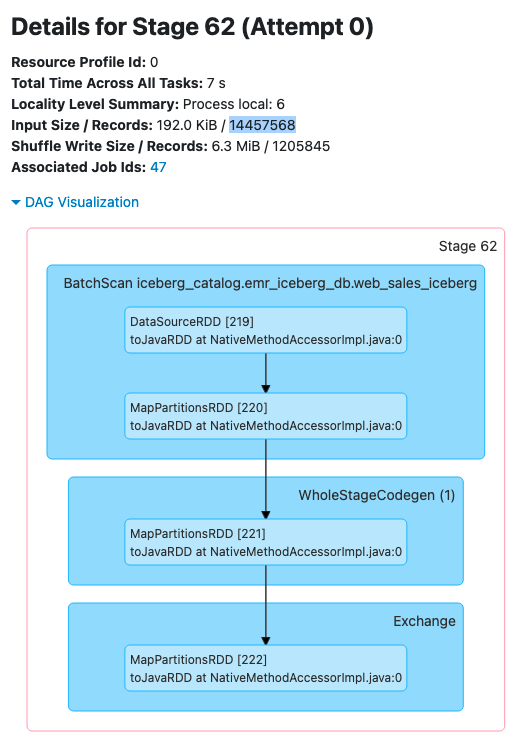
</div>

Esa es exactamente la cantidad de registros de la partición del año 2000, lo cual demuestra que la poda de particiones se realizó correctamente y que solo se inspeccionaron los registros de la partición 2000.


In [ ]:
%%sql
SELECT YEAR(ws_sales_time) as year, COUNT(*) AS records_per_year
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
GROUP BY YEAR(ws_sales_time)
ORDER BY year

La misma consulta anterior haría un escaneo completo de la tabla en una tabla Hive, porque el campo de partición **year** no está incluido como parte del filtro. Los usuarios finales tendrían que entender muy bien la estructura de particionado y reescribir la consulta como sigue para aprovechar las particiones de datos de manera eficiente.

```
SELECT count(distinct(ws_order_number))
FROM iceberg_db.sales.web_sales_iceberg
WHERE ws_sales_time >= TIMESTAMP('2000-01-01 00:00:00') AND ws_sales_time < TIMESTAMP('2001-01-01 00:00:00') AND year='2000'
```

El particionado oculto aporta los siguientes beneficios:

1. Iceberg se encarga de la tarea propensa a errores de producir valores de partición para las filas de una tabla.
2. Iceberg evita leer particiones innecesarias de forma automática. Los consumidores no necesitan saber cómo está particionada la tabla ni agregar filtros extra a sus consultas.


## Captura de cambios con Merge


Hasta este punto has trabajado con tablas donde los datos solo se insertan. Sin embargo, en escenarios como la captura de cambios (CDC), los registros podrían necesitar ser insertados o actualizados bajo ciertas condiciones. En la siguiente sección aprenderás a usar la sentencia Merge Into para hacer *upsert* desde una fuente CDC hacia una tabla Iceberg.

Iceberg soporta la fusión de cambios hechos en una fuente de datos hacia tablas Iceberg mediante la sentencia SQL `MERGE INTO`. MERGE permite inserciones, actualizaciones y eliminaciones dentro de una sola operación.
Consulta la [documentación de Iceberg](https://iceberg.apache.org/docs/latest/spark-writes/#merge-into) para entender la sintaxis y la semántica en detalle.

A continuación, con una sola operación vas a:
- insertar datos para el año 2001
- actualizar el ID de bodega de 10 a 16 para registros del año 2000
- eliminar registros del año 1999 con el ID de bodega establecido en 9

Para hacerlo, creas una tabla temporal `merge_table`, que es la unión de inserciones, actualizaciones y eliminaciones. Cada registro contiene una columna `operation` que indica si es una inserción (I), una actualización (U) o una eliminación (D).


In [ ]:
insert_df=spark.sql(f"""
SELECT ws_order_number, ws_item_sk, ws_quantity, ws_sales_price, ws_warehouse_sk, ws_sales_time, 'I' as operation
FROM spark_catalog.{TPC_DS_DATABASE}.{TPC_DS_SALES_TABLE} where year(ws_sales_time) = 2001
"""
)

update_df=spark.sql(f"""
SELECT ws_order_number, ws_item_sk, ws_quantity, ws_sales_price, 16 AS ws_warehouse_sk, ws_sales_time, 'U' as operation  
FROM spark_catalog.{TPC_DS_DATABASE}.{TPC_DS_SALES_TABLE} where year(ws_sales_time) = 2000 AND ws_warehouse_sk = 10
"""
)

delete_df=spark.sql(f"""
SELECT ws_order_number, ws_item_sk, ws_quantity, ws_sales_price, ws_warehouse_sk, ws_sales_time, 'D' as operation  
FROM spark_catalog.{TPC_DS_DATABASE}.{TPC_DS_SALES_TABLE} where year(ws_sales_time) = 1999 AND ws_warehouse_sk = 9
"""
)


insert_count=insert_df.count()
update_count=update_df.count()
delete_count=delete_df.count()

#union the 3 previously created dataframes inside a single one 
merge_df=insert_df.union(update_df).union(delete_df)

#create a temporary view called `merge_table` with the unioned dataframe
merge_df.createOrReplaceTempView("merge_table")

print(f"Records which will be inserted: {insert_count}")
print(f"Records which will be updated: {update_count}")
print(f"Records which will be deleted: {delete_count}")

Vamos a hacer el merge de la tabla temporal `merge_table` con la tabla Iceberg. La operación puede tardar 1 a 2 minutos en completarse.


In [ ]:
%%sql
MERGE INTO ${ICEBERG_DB}.${ICEBERG_SALES_TABLE} t
USING merge_table s
    ON t.ws_order_number = s.ws_order_number AND t.ws_item_sk = s.ws_item_sk
WHEN MATCHED AND s.operation like 'D' THEN DELETE
WHEN MATCHED AND s.operation like 'U' THEN UPDATE SET t.ws_order_number = s.ws_order_number, t.ws_item_sk = s.ws_item_sk, t.ws_quantity = s.ws_quantity, t.ws_sales_price = s.ws_sales_price, t.ws_warehouse_sk = s.ws_warehouse_sk, t.ws_sales_time = s.ws_sales_time
WHEN NOT MATCHED THEN INSERT (ws_order_number, ws_item_sk, ws_quantity, ws_sales_price, ws_warehouse_sk, ws_sales_time) VALUES (s.ws_order_number, s.ws_item_sk, s.ws_quantity, s.ws_sales_price, s.ws_warehouse_sk, s.ws_sales_time)

In [ ]:
show_tables_files(ICEBERG_SALES_TABLE)

Ahora puedes validar que tienes datos para el año 2001 (las inserciones se aplicaron correctamente).


In [ ]:
%%sql
SELECT YEAR(ws_sales_time) AS year, COUNT(*) as records_per_year
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
GROUP BY (YEAR(ws_sales_time))
ORDER BY year

Puedes validar que no existe ninguna fila con el ID de bodega establecido en 10 para el año 2000 y que, en su lugar, tienes filas con el ID de bodega establecido en 16 (las actualizaciones se aplicaron correctamente).


In [ ]:
%%sql
SELECT ws_warehouse_sk, COUNT(*) as records_per_warehouse
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
WHERE YEAR(ws_sales_time) = 2000
GROUP BY ws_warehouse_sk
ORDER BY ws_warehouse_sk

Puedes ver en la tabla que no tienes ninguna fila con el ID de bodega establecido en 9 para el año 1999 (las eliminaciones se aplicaron correctamente).


In [ ]:
%%sql
SELECT ws_warehouse_sk, COUNT(*) as records_per_warehouse
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
WHERE YEAR(ws_sales_time) = 1999
GROUP BY ws_warehouse_sk
ORDER BY ws_warehouse_sk

Al revisar el resumen del último snapshot creado por la operación MERGE, podemos ver que:
- hay 3 **changed-partition-count** (el MERGE tocó las particiones de los años 1999, 2000 y 2001)
- la cantidad de **deleted-data-files** refleja el número de archivos que teníamos dentro de las particiones 1999 y 2000 antes de ejecutar el MERGE (las operaciones DELETE y UPDATE dentro del MERGE impactaron registros presentes en todos los archivos de datos de las particiones 1999 y 2000).


In [ ]:
df=spark.sql(f"""
SELECT summary
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at DESC
""")

print(json.dumps(df.first()['summary'], sort_keys=True, indent=4))

## Mantenimiento de tablas


### Expiración de snapshots


Por defecto, Iceberg no elimina los snapshots creados por transacciones. Como resultado, puedes realizar operaciones como consultas de *time travel*, revertir el snapshot actual de la tabla a uno anterior, o crear una vista de captura de cambios (es decir, una vista que muestra los cambios entre dos snapshots).

Como pudiste ver, en tablas *copy-on-write*, cuando hay cambios en la tabla Iceberg (actualizaciones o eliminaciones), los archivos de datos asociados con los registros impactados se duplican y se actualizan. Esto significa que el snapshot más reciente apunta a los archivos vigentes, mientras que snapshots antiguos pueden apuntar a archivos previos (que contienen una versión anterior de un registro).

Aunque tener múltiples snapshots permite realizar esas operaciones, también hay consideraciones. Por ejemplo, mantener más archivos de metadatos implica que el costo de almacenamiento también crecerá. Una forma simple de evitar que la tabla crezca indefinidamente es definir una ventana de tiempo que se ajuste a tus necesidades de *time travel*, rollbacks o captura de cambios y eliminar snapshots (junto con sus archivos obsoletos referenciados) que sean más antiguos que esa ventana (por ejemplo, 30 días).

A continuación verás cómo expirar snapshots con el procedimiento de tabla [expire_snapshots](https://iceberg.apache.org/docs/latest/spark-procedures/#expire_snapshots). Este procedimiento elimina snapshots antiguos y archivos de datos que solo son necesarios para esos snapshots antiguos. El procedimiento `expire_snapshots` nunca eliminará archivos que todavía sean requeridos por un snapshot que no haya expirado.


En este momento tienes 7 snapshots. Seis snapshots fueron generados con operaciones append (INSERT) y uno con overwrite (MERGE).


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at

Vamos a expirar el primer snapshot.


In [ ]:
expire_time_df=spark.sql(f"""
SELECT committed_at FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at
"""
)

expire_time_ts=expire_time_df.collect()[0][0]

expire_time_ts_plus1 =  str(expire_time_ts + timedelta(seconds=1))

print(f"Expire Snapshots older than: {expire_time_ts_plus1}")

expire_snapshot_df=spark.sql(f"""
CALL system.expire_snapshots(table => '`{ICEBERG_DB}`.`{ICEBERG_SALES_TABLE}`', older_than => TIMESTAMP '{expire_time_ts_plus1}')
"""
)

El dataframe de salida contiene estadísticas sobre la operación de expiración, como el número de archivos de datos eliminados, archivos de manifiesto y archivos de listas de manifiestos.


In [ ]:
expire_snapshot_df.show(truncate=False, vertical=True)

Puedes ver que el primer snapshot ha sido eliminado.


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at

Revisemos la cantidad actual de archivos por partición.


In [ ]:
show_data_files_count(ICEBERG_SALES_TABLE)

Vamos a expirar todos los snapshots excepto el último. Esta operación es útil para eliminar registros de forma irreversible en el contexto de leyes de cumplimiento como el derecho al olvido (GDPR).


In [ ]:
timenow = str(datetime.now())

expire_snapshot_df=spark.sql(f"""
CALL system.expire_snapshots(table => '`{ICEBERG_DB}`.`{ICEBERG_SALES_TABLE}`', older_than => TIMESTAMP '{timenow}',  retain_last => 1)
"""
)

In [ ]:
expire_snapshot_df.show(truncate=False, vertical=True)

Ahora puedes ver que solo el snapshot más reciente está disponible.


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at

Puedes ver que la cantidad total de archivos se redujo para incluir solo los archivos vigentes (archivos apuntados por el snapshot actual).


In [ ]:
show_data_files_count(ICEBERG_SALES_TABLE)

### Compactación de datos


Iceberg rastrea cada archivo de datos en una tabla. Más archivos de datos implican más metadatos almacenados en archivos de manifiesto, y los archivos pequeños generan una cantidad innecesaria de metadatos y consultas menos eficientes por el costo de abrir archivos. Más importante aún, las consultas deben procesar muchos archivos en sus manifiestos y listas de manifiestos, además del costo de apertura de archivos.

Iceberg te permite redimensionar tus archivos de forma programática a un tamaño óptimo para consultas. Puedes definir un tamaño objetivo de archivo y asegurarte de que las lecturas estén optimizadas para un buen rendimiento. Puedes hacerlo usando el procedimiento de tabla [**rewrite_data_files**](https://iceberg.apache.org/docs/latest/spark-procedures/#rewrite_data_files).


Revisemos la cantidad actual de archivos por partición con su tamaño asociado. Para ello usamos la tabla de metadatos **files**. Más adelante profundizaremos en las tablas de metadatos.


In [ ]:
spark.sql(f"""
SELECT partition, count(*) as num_files, collect_list( ROUND((file_size_in_bytes / 1024 / 1024), 2)) as file_size_in_megabytes
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}.files
GROUP BY partition 
ORDER BY partition
"""
).show(truncate=False)

Ten en cuenta que la transformación de partición **year** extrae el año de una fecha o timestamp como “años desde 1970” (por ejemplo, year=2000 => year=30). Consulta más información en la sección [Partitions Transforms](https://iceberg.apache.org/spec/#partition-transforms) de la documentación de Iceberg.


Tomemos 100 líneas de un archivo perteneciente a la partición del año 1998. Podemos ver que los registros no están ordenados por la columna `ws_order_number` dentro del archivo.


In [ ]:
partition_1998_file=spark.sql(f"""
SELECT input_file_name() as file_name
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}
WHERE year(ws_sales_time) = 1998
LIMIT 1
"""
).collect()[0]["file_name"]

df=spark.read.parquet(partition_1998_file)
df.show(100)

Tus analistas y científicos de datos empezarán a quejarse del rendimiento de consultas con el layout de datos anterior. Planeas fusionar archivos pequeños para mejorar el rendimiento. Además, planeas ordenar los datos por *order_number* para que los registros queden agrupados de forma consistente. En este caso, cuando una consulta busca un `ws_order_number` específico, el planificador de consultas puede usar las estadísticas de columnas y omitir cualquier archivo de datos cuyo `ws_order_number` no coincida fuera del predicado (poda de archivos).


Usarás el procedimiento *rewrite_data_files* no solo para empaquetar los archivos al tamaño deseado, sino también para ordenarlos según las columnas especificadas (`ws_order_number`). Ten en cuenta que esta opción hace más lenta la reescritura debido a la fase de ordenamiento.

Para Iceberg 1.4.0+ existen los siguientes valores por defecto que impactan el procedimiento *rewrite_data_files*:
- **target-file-size-bytes = 536870912 (512 MB)**: tamaño objetivo de archivo de salida
- **min-file-size-bytes = 75% of target-file-size-bytes (384 MB)**: archivos por debajo de este tamaño se considerarán para reescritura
- **max-file-size-bytes = 180% of target-file-size-bytes (921.6 MB)**: archivos por encima de este tamaño se considerarán para reescritura
- **min-input-files = 5**: dentro de una partición, necesitamos al menos esta cantidad de archivos para disparar una compactación (los grupos de archivos que excedan este número se reescribirán)
- **max-concurrent-file-group-rewrite = 5**: cantidad máxima de grupos de archivos que se pueden reescribir en paralelo
- **max-file-group-size-bytes = 107374182400 (100GB)**: cantidad máxima de datos que se debería reescribir en un solo grupo de archivos

Todos estos valores pueden modificarse usando el parámetro **options**. Para más información, revisa la sección [rewrite_data_files](https://iceberg.apache.org/docs/latest/spark-procedures/#rewrite_data_files) de la documentación de Iceberg.

Ten en cuenta que un grupo de archivos marcado para reescritura (compactación) solo incluye archivos dentro de una sola partición (los grupos de archivos no abarcan múltiples particiones).

Compactemos nuestra tabla con un ordenamiento por la columna `ws_order_number`. Este procedimiento puede tardar aproximadamente 30 segundos.


In [ ]:
compaction_df=spark.sql(f"""
CALL system.rewrite_data_files(
table => '`{ICEBERG_DB}`.`{ICEBERG_SALES_TABLE}`', 
strategy => 'sort', 
sort_order => 'ws_order_number ASC NULLS LAST'
)
"""
)

In [ ]:
compaction_df.show(truncate=False)

A continuación puedes ver la nueva cantidad de archivos por partición con su tamaño asociado. En particular, observa cómo los archivos de la partición 1998 se compactaron a 1.


In [ ]:
spark.sql(f"""
SELECT partition, count(*) as num_files, collect_list( ROUND((file_size_in_bytes / 1024 / 1024), 2)) as file_size_in_megabytes
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}.files
GROUP BY partition 
ORDER BY partition
"""
).show(truncate=False)

**Ten en cuenta que solo los archivos compactados quedan ordenados**. Por ejemplo, puedes ver que los registros están ordenados por la columna `ws_order_number` en el archivo generado dentro de la partición del año 1998.


In [ ]:
partition_1998_file=spark.sql(f"""
SELECT input_file_name() as file_name
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}
WHERE year(ws_sales_time) = 1998
LIMIT 1
"""
).collect()[0]["file_name"]

df=spark.read.parquet(partition_1998_file)
df.show(100)

Ten en cuenta que la operación de compactación genera un nuevo snapshot de tipo `replace`:


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at

### Evolución de particiones


El patrón de consulta de tus tablas evoluciona con el tiempo a medida que cambian los casos de uso y los insights que necesitan tus consumidores. Como consecuencia, tendrás que particionar los datos de manera distinta para ajustarte a nuevos patrones de acceso; sin embargo, con tablas Hive esto es una tarea costosa y compleja porque debes reescribir las tablas para cambiar la partición.

El particionado de tablas Iceberg puede actualizarse sin necesidad de reescribir las tablas existentes, porque las consultas no referencian valores de partición de forma directa. Cuando evolucionas un *partition spec*, los datos antiguos escritos con un spec anterior permanecen sin cambios. Los datos nuevos se escriben usando el nuevo spec en un layout nuevo. Los metadatos de cada versión de particionado se mantienen por separado. Por esto, cuando empiezas a ejecutar consultas, obtienes *split planning*: cada layout de partición planifica archivos por separado usando el filtro que deriva para ese layout específico.

En la siguiente sección verás cómo evolucionar la partición de la tabla *in-place* según sea necesario.

Actualmente, tu tabla está particionada por año.


In [ ]:
show_tables_files(ICEBERG_SALES_TABLE)

Ahora consideremos un escenario donde el volumen de ventas crece 10X en el año 2002. Con este aumento significativo en volumen, particionar solo por año podría dejar de ser óptimo para el rendimiento de consultas. En este caso, necesitas evolucionar el esquema de particionado de “año de venta” a “mes de venta” para obtener mayor granularidad.

Esta evolución de partición se puede lograr con un comando `ALTER TABLE` con la cláusula `REPLACE`, cambiando el campo de partición de `years(ws_sales_time)` a `months(ws_sales_time)`.


In [ ]:
%%sql
ALTER TABLE ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
REPLACE PARTITION FIELD years(ws_sales_time) 
WITH months(ws_sales_time)

Puedes verificar que la partición cambió a `months(ws_sales_time)` con la siguiente consulta.


In [ ]:
spark.sql(f"""
DESCRIBE TABLE {ICEBERG_DB}.{ICEBERG_SALES_TABLE}
"""
).show(truncate=False)

Puedes ver que no cambió nada en los datos actuales de la tabla. Esto se debe a que la evolución de particiones es una operación de metadatos y no reescribe archivos de forma inmediata.


In [ ]:
show_tables_files(ICEBERG_SALES_TABLE)

La nueva partición se aplicará a todos los datos nuevos. Insertemos los datos de 2002 para validar.


In [ ]:
%%sql
INSERT INTO ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
SELECT *
FROM spark_catalog.${TPC_DS_DATABASE}.${TPC_DS_SALES_TABLE} where year(ws_sales_time) = 2002

Revisemos ahora la carpeta de datos de la tabla.


In [ ]:
show_tables_files(ICEBERG_SALES_TABLE)

Puedes ver que los datos hasta el año 2000 están particionados por año. A partir de 2002, la tabla queda particionada por mes. Ambos layouts de particionado pueden coexistir en la misma tabla. Gracias al particionado oculto, no necesitas escribir consultas específicas para un layout de particionado para obtener buen rendimiento. En su lugar, puedes escribir consultas que seleccionen los datos que necesitas y Iceberg elimina automáticamente los archivos que no contienen datos coincidentes.

Con la siguiente consulta, contamos órdenes distintas para el 1 de enero de 2000 y el 1 de enero de 2002. Con particionado oculto, solo se inspeccionan las particiones específicas (ws_sales_time_year=2000 y ws_sales_time_month=2002-01).


In [ ]:
%%sql
SELECT COUNT(DISTINCT(ws_order_number)) AS num_orders, year(ws_sales_time) as year, month(ws_sales_time) as month
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
WHERE (ws_sales_time >= TIMESTAMP('2000-01-01 00:00:00') AND ws_sales_time < TIMESTAMP('2000-01-02 00:00:00')) OR (ws_sales_time >= TIMESTAMP('2002-01-01 00:00:00') AND ws_sales_time < TIMESTAMP('2002-01-02 00:00:00'))
GROUP BY year(ws_sales_time), month(ws_sales_time)
ORDER BY year(ws_sales_time), month(ws_sales_time)

Como podemos ver en los jobs de Spark ejecutados, el valor Input Size/Records para la etapa inicial BatchScan muestra **15298572** como conteo de registros.


<div>
    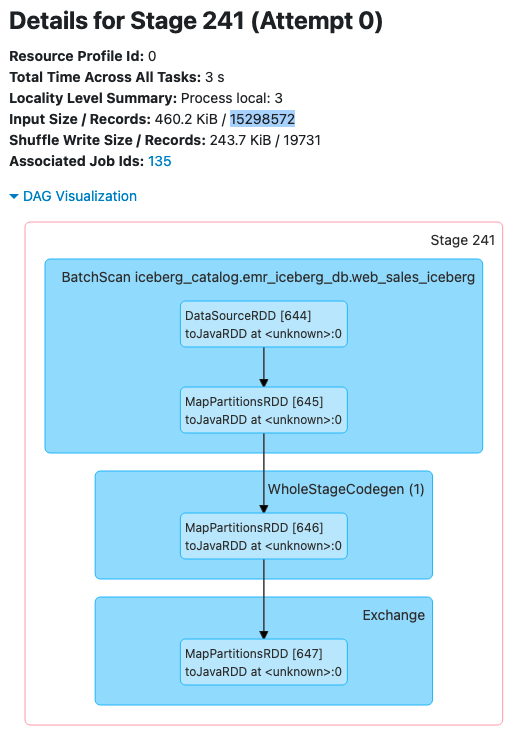
</div>

Esa es exactamente la suma de la cantidad de registros de la partición del año 2000 y los registros de la partición de enero de 2002. Esto demuestra que la poda de particiones se realizó correctamente y que solo se inspeccionaron los registros de la partición ws_sales_time_year=2000 y de la partición ws_sales_time_month=2002-01.


In [ ]:
%%sql
SELECT SUM(records) AS total_records_2000_and_january_2002 FROM
(
SELECT COUNT(*) AS records
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
WHERE YEAR(ws_sales_time) = 2000

UNION

SELECT COUNT(*) AS records
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}
WHERE MONTH(ws_sales_time) = 1 AND YEAR(ws_sales_time)=2002
)

## Metadatos de tabla [Opcional]


Iceberg proporciona una forma de consultar metadatos de tablas. Para cualquier tabla con nombre **table_name**, puedes acceder a sus tablas de metadatos consultando **table_name.metadata_table**. A continuación se muestran algunas de las tablas de metadatos que tiene cada tabla Iceberg.


### history <a class="anchor" id="history"></a>

Iceberg ofrece una forma de ver el historial de acciones realizadas sobre tu tabla usando la tabla de metadatos **history**.

Aquí hay un ejemplo de acceso a la tabla history con Spark SQL. Podemos ver que solo se aplicaron 3 cambios a nuestra tabla, porque cambios anteriores fueron descartados por el procedimiento **expire_snapshots**. En particular, los 3 cambios están relacionados con estas 3 operaciones que ejecutamos:
1. merge
2. rewrite_data_files
3. insert (datos para el año 2002)


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.history
ORDER BY made_current_at

La tabla history muestra lo siguiente para cada operación:

- el tiempo de commit
- el snapshot_id
- el snapshot_id del snapshot anterior (parent_id)
- si el commit forma parte de los ancestros activos (is_current_ancestor). En caso de que el commit haya sido revertido (*rolled back*), este valor se establece en False y verás múltiples snapshots con el mismo parent_id.


### snapshots <a class="anchor" id="snapshots"></a>

Para encontrar información detallada de cada snapshot de tu tabla, puedes consultar la tabla **snapshots**. Esto es útil al diagnosticar problemas para revisar cuántos archivos nuevos se crearon como resultado de una operación específica (por ejemplo, amplificación de escritura).


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at

La tabla snapshots muestra para cada snapshot:

* el tiempo de commit del snapshot (committed_at)
* el snapshot_id
* el snapshot_id del snapshot anterior (parent_id)
* la operación que creó cada snapshot (por ejemplo, append, overwrite, replace)
* la ubicación del archivo manifest_list creado durante ese snapshot
* un resumen de los cambios correspondientes a ese snapshot, como:
    * número de archivos agregados (added-data-files)
    * tamaño total de los archivos agregados (added-files-size)
    * número de registros agregados (added-records)
    * número de particiones impactadas (changed-partition-count)
    * número de archivos eliminados (deleted-data-files)
    * número de registros eliminados (deleted-records)
    * tamaño de los archivos eliminados (removed-files-size)
    * el ID de la aplicación que ejecutó la operación (spark.app.id)
    * si trabajamos con tablas Merge-on-read, el tipo de delete realizado y su cantidad (total-equality-deletes o total-position-deletes)
    * la cantidad actual de registros de la tabla (total-records)

Veamos en detalle el resumen del último snapshot.


In [ ]:
df=spark.sql(f"""
SELECT summary
FROM {ICEBERG_DB}.{ICEBERG_SALES_TABLE}.snapshots
ORDER BY committed_at DESC
""")

print(json.dumps(df.first()['summary'], sort_keys=True, indent=4))

### files <a class="anchor" id="files"></a>

Iceberg permite obtener información sobre los archivos activos actuales de la tabla (archivos que pertenecen al snapshot actual). Esto es útil al diagnosticar problemas de calidad de datos y de rendimiento.


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.files LIMIT 3

La tabla files muestra, para cada archivo de datos activo actual:

* la ubicación del archivo (file_path)
* el formato del archivo (file_format)
* la partición a la que pertenece el archivo (partition)
* la cantidad de registros dentro del archivo (record_count)
* el tamaño del archivo (file_size_in_bytes)
* estadísticas de columnas, por ejemplo para cada columna:
    * cantidad de registros con valor (value_counts)
    * cantidad de registros con valores nulos (null_value_counts)
    * cantidad de registros con valores NaN (nan_value_counts)
    * valor máximo (upper_bounds)
    * valor mínimo (lower_bounds)

Notas:
* la transformación de partición **year** extrae el año de una fecha o timestamp como “años desde 1970” (por ejemplo, year=2001 => year=31). Consulta más información en la sección [Partitions Transforms](https://iceberg.apache.org/spec/#partition-transforms) de la documentación de Iceberg
* cada columna se mapea a un id de columna (por ejemplo, 1, 2, 3, ...). Veremos más detalles sobre esto más adelante en la sección [Schema Evolution](#schema_evol).

Estos insights son valiosos cuando quieres optimizar el rendimiento de consultas y también al diagnosticar problemas de calidad de datos. En particular, al revisar los tamaños de archivo en la tabla de metadatos files, puedes decidir con qué frecuencia necesitas ejecutar compactaciones. Aquí tienes algunas consultas útiles.


Mostrar:
- Promedio del tamaño de archivos activos en MB
- Mediana del tamaño de archivos activos en MB
- Tamaño total de archivos activos en MB
- Número de archivos activos


In [ ]:
%%sql
SELECT avg(file_size_in_bytes)/1024/1024 as average_file_size_mb, percentile(file_size_in_bytes, 0.5)/1024/1024 as median_file_size_mb, count(*) as num_files, sum(file_size_in_bytes)/1024/1024 as total_file_size_in_mb
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.files

Mostrar la misma información que la consulta anterior, pero para cada partición.


In [ ]:
%%sql
SELECT partition, avg(file_size_in_bytes)/1024/1024 as average_file_size_mb,  percentile(file_size_in_bytes, 0.5)/1024/1024 as median_file_size_mb, count(*) as num_files, sum(file_size_in_bytes)/1024/1024 as total_file_size_in_mb
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.files
GROUP BY partition

Mostrar el porcentaje de archivos activos que son menores a 64 MB.


In [ ]:
%%sql
SELECT cast(sum(case when file_size_in_bytes < 64*1024*1024 then 1 else 0 end)*100/count(*) as decimal(10,2)) as percentage_of_small_files
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.files

### all_files <a class="anchor" id="all_files"></a>

Mientras que la tabla de metadatos `files` de Iceberg permite obtener información sobre los archivos activos actuales de la tabla (archivos que pertenecen al snapshot actual), la tabla de metadatos `all_files` permite obtener información sobre todos los archivos de datos presentes en el almacenamiento (para todos los snapshots).


In [ ]:
%%sql
SELECT * FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.all_files LIMIT 3

Se pueden hacer consultas similares a las de la tabla `files` sobre la tabla `all_files`.
Por ejemplo, podemos revisar la cantidad total de archivos y el tamaño total de archivos para entender cuál es la presión actual de almacenamiento de nuestra tabla.


In [ ]:
%%sql
SELECT count(*) as num_files, sum(file_size_in_bytes)/1024/1024 as total_file_size_in_mb
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.all_files

Mostrar la misma información que la consulta anterior, pero para cada partición


In [ ]:
%%sql
SELECT partition, avg(file_size_in_bytes)/1024/1024 as average_file_size_mb,  percentile(file_size_in_bytes, 0.5)/1024/1024 as median_file_size_mb, count(*) as num_files, sum(file_size_in_bytes)/1024/1024 as total_file_size_in_mb
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.all_files
GROUP BY partition

### manifests <a class="anchor" id="manifests"></a>


En Iceberg, cada snapshot de tabla está asociado con un archivo de lista de manifiestos (*manifest list*). Cada lista de manifiestos apunta a uno o varios archivos de manifiesto (*manifest*).

Iceberg permite obtener información sobre los manifiestos actuales apuntados por la lista de manifiestos del snapshot actual.


In [ ]:
%%sql
SELECT *
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.manifests

La tabla manifests muestra, para cada archivo de manifiesto actual:

* la ubicación del archivo de manifiesto (path)
* el tamaño del archivo de manifiesto en bytes (length)
* el snapshot_id relacionado (added_snapshot_id)
* la cantidad de archivos en el manifiesto con estado ADDED (archivos agregados por la operación actual - added_data_files_count)
* la cantidad de archivos en el manifiesto con estado EXISTING (archivos que ya existían antes de la operación actual - existing_data_files_count)
* la cantidad de archivos en el manifiesto con estado DELETED (archivos marcados como eliminados por la operación actual - deleted_data_files_count)
* estadísticas a nivel de partición

La columna **partition_summaries** en la tabla **manifests** contiene estadísticas **lower_bound** y **upper_bound** para columnas de partición a nivel de manifiesto. Grupos completos de archivos dentro de cada manifiesto se pueden omitir al buscar valores de partición específicos, acelerando la ejecución (por ejemplo, consultas con un filtro sobre el valor de la partición como `WHERE year(ws_sales_time) = XX`).


### partitions <a class="anchor" id="partitions"></a>

Iceberg permite obtener información sobre las particiones actuales.


In [ ]:
%%sql
SELECT *
FROM ${ICEBERG_DB}.${ICEBERG_SALES_TABLE}.partitions

La tabla partitions muestra para cada partición actual:

* las claves de partición (partition)
* la cantidad de registros contenidos en la partición (record_count)
* la cantidad de archivos contenidos en la partición (file_count)
* la última vez que se actualizó la partición (last_updated_at)

Ten en cuenta que `record_count` y `file_count` consideran solo archivos activos que pertenecen al snapshot actual.

Esta información es útil para diagnosticar *partition skew* y adoptar una estrategia de particionado más uniforme.


## Limpieza [NO EJECUTAR a menos que quieras recrear los datasets] <a class="anchor" id="cleanup"></a>


Los comandos de abajo eliminan del catálogo la base de datos y la tabla Iceberg creadas, así como los archivos relacionados en S3.


In [ ]:
#Remove the created Iceberg table
spark.sql(f"DROP TABLE {ICEBERG_DB}.{ICEBERG_SALES_TABLE} PURGE")

In [ ]:
#Remove the created Iceberg database
spark.sql(f"DROP DATABASE {ICEBERG_DB}")